# EfficientNet-B0 FER2013 Experiments

Focused transfer-learning notebook for EfficientNet-B0. This keeps EfficientNet experiments separate from ResNet18 so results and configs are easier to report.

In [1]:
from pathlib import Path
import json
import random
import sys

import importlib
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'fer2013_images'
# Kaggle option:
# DATA_DIR = Path('/kaggle/input/datasets/msambare/fer2013')

RESULTS_DIR = PROJECT_ROOT / 'results'
(RESULTS_DIR / 'checkpoints').mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'metrics').mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'figures').mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE, DATA_DIR

(device(type='cuda'), PosixPath('/kaggle/working/data/raw/fer2013_images'))

## Kaggle Path Setup Option

Use this block only when running the notebook in Kaggle. It clones or updates the repository, then points `DATA_DIR` to the Kaggle FER2013 dataset folder.

In [2]:
# Kaggle option. Uncomment this block only when running in Kaggle.

%cd /kaggle/working
from pathlib import Path
import sys

REPO_URL = 'https://github.com/zsykk/DL-final-project.git'
REPO_DIR = 'DL-final-project'

if Path(REPO_DIR).exists():
    %cd /kaggle/working/DL-final-project
    !git pull
else:
    !git clone {REPO_URL}
    %cd /kaggle/working/DL-final-project

PROJECT_ROOT = Path('/kaggle/working/DL-final-project')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
DATA_DIR = Path('/kaggle/input/datasets/msambare/fer2013')
RESULTS_DIR = PROJECT_ROOT / 'results'
(RESULTS_DIR / 'checkpoints').mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'metrics').mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'figures').mkdir(parents=True, exist_ok=True)

DATA_DIR, (DATA_DIR / 'train').exists(), (DATA_DIR / 'test').exists(), PROJECT_ROOT

/kaggle/working
Cloning into 'DL-final-project'...
remote: Enumerating objects: 163, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 163 (delta 5), reused 10 (delta 3), pack-reused 148 (from 1)
Receiving objects: 100% (163/163), 89.07 MiB | 35.37 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/kaggle/working/DL-final-project


(PosixPath('/kaggle/input/datasets/msambare/fer2013'),
 True,
 True,
 PosixPath('/kaggle/working/DL-final-project'))

In [3]:
from fer_project.data import TransformConfig, build_imagefolder_dataloaders, class_weights, dataset_labels
from fer_project.models import build_model

import fer_project.training as training
training = importlib.reload(training)
fit = training.fit

import fer_project.metrics as metrics
metrics = importlib.reload(metrics)
collect_predictions = metrics.collect_predictions
plot_training_and_confusion = metrics.plot_training_and_confusion
save_classification_report = metrics.save_classification_report
top_confusions = metrics.top_confusions

In [4]:
TRANSFER_TRAIN_CONFIG = TransformConfig(image_size=224, channels=3, augment=True, imagenet_norm=True)
TRANSFER_EVAL_CONFIG = TransformConfig(image_size=224, channels=3, augment=False, imagenet_norm=True)

def save_experiment_config(name, config):
    path = RESULTS_DIR / 'metrics' / f'{name}_config.json'
    with open(path, 'w') as f:
        json.dump(config, f, indent=2, default=str)
    return path

def build_transfer_loaders(batch_size=64, num_workers=0, subset_fraction=1.0, weighted_sampler=False):
    return build_imagefolder_dataloaders(
        DATA_DIR,
        train_config=TRANSFER_TRAIN_CONFIG,
        eval_config=TRANSFER_EVAL_CONFIG,
        batch_size=batch_size,
        num_workers=num_workers,
        weighted_sampler=weighted_sampler,
        val_fraction=0.1,
        subset_fraction=subset_fraction,
        seed=SEED,
    )

def set_efficientnet_b0_trainable_layers(model, unfreeze_from='classifier'):
    for parameter in model.parameters():
        parameter.requires_grad = False
    if unfreeze_from == 'classifier':
        modules = [model.classifier]
    elif unfreeze_from == 'last_block':
        modules = [model.features[-1], model.classifier]
    elif unfreeze_from == 'last_blocks':
        modules = [model.features[-2], model.features[-1], model.classifier]
    elif unfreeze_from == 'last_three_blocks':
        modules = [model.features[-3], model.features[-2], model.features[-1], model.classifier]
    elif unfreeze_from == 'all':
        modules = [model]
    else:
        raise ValueError("unfreeze_from must be 'classifier', 'last_block', 'last_blocks', 'last_three_blocks', or 'all'")
    for module in modules:
        for parameter in module.parameters():
            parameter.requires_grad = True
    return model

def finalize_model_run(model, loaders, history, name, checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    y_true, y_pred = collect_predictions(model, loaders['test'], DEVICE)
    report = save_classification_report(y_true, y_pred, RESULTS_DIR / 'metrics' / f'{name}_classification_report.csv')
    confusions = top_confusions(y_true, y_pred, top_n=10)
    confusions.to_csv(RESULTS_DIR / 'metrics' / f'{name}_top_confusions.csv', index=False)
    history_frame = pd.DataFrame(history)
    history_frame.to_csv(RESULTS_DIR / 'metrics' / f'{name}_history.csv', index=False)
    plot_training_and_confusion(
        history_frame,
        y_true,
        y_pred,
        f'{name}: loss and confusion matrix',
        RESULTS_DIR / 'figures' / f'{name}_confusion_matrix.png',
    )
    print(f'Best checkpoint saved to: {checkpoint_path}')
    display(report.loc[['macro avg', 'weighted avg']])
    display(report.loc[['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral'], ['precision', 'recall', 'f1-score', 'support']])
    display(confusions)
    return history_frame, report, confusions

## Gradual Unfreeze

Trains EfficientNet-B0 in stages: classifier first, then progressively later feature blocks. Total epochs = `len(unfreeze_stages) * epochs_per_stage`.

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 129MB/s] 


  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

...

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

{'stage': 'unfreeze_all', 'epoch': 25, 'stage_epoch': 5, 'lr': 0.0, 'train_loss': 0.8421, 'train_macro_f1': 0.6598, 'train_weighted_f1': 0.686, 'val_loss': 0.979, 'val_macro_f1': 0.6114, 'val_weighted_f1': 0.6426}


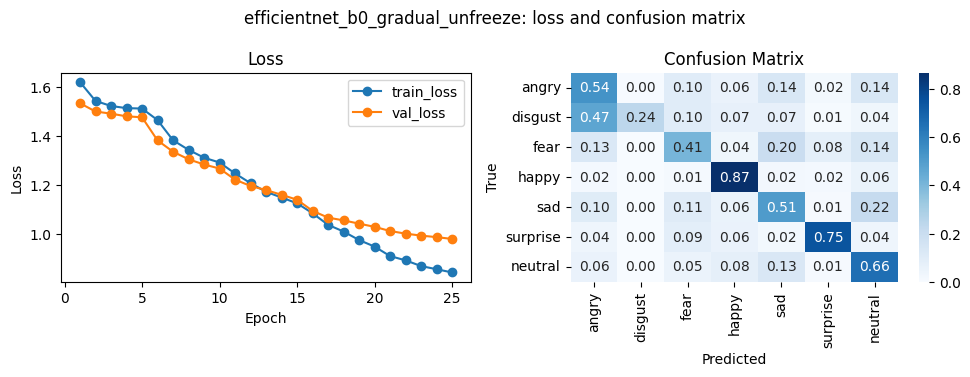

Best checkpoint saved to: /kaggle/working/DL-final-project/results/checkpoints/efficientnet_b0_gradual_unfreeze.pt


,precision,recall,f1-score,support
macro avg,0.641827,0.567238,0.583126,7178.0
weighted avg,0.635421,0.635971,0.631598,7178.0


,precision,recall,f1-score,support
angry,0.533058,0.538622,0.535826,958.0
disgust,0.771429,0.243243,0.369863,111.0
fear,0.509135,0.408203,0.453117,1024.0
happy,0.828756,0.867531,0.847700,1774.0
sad,0.524086,0.506014,0.514892,1247.0
surprise,0.785354,0.748496,0.766482,831.0
neutral,0.540973,0.658556,0.594001,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
28,sad,neutral,273,0.218925
15,fear,sad,205,0.200195
38,neutral,sad,166,0.134631
17,fear,neutral,148,0.144531
25,sad,fear,133,0.106656
3,angry,sad,132,0.137787
5,angry,neutral,131,0.136743
12,fear,angry,129,0.125977
23,sad,angry,127,0.101844
37,neutral,happy,99,0.080292


In [5]:
def fit_efficientnet_b0_gradual_unfreeze(
    model,
    loaders,
    device,
    unfreeze_stages=('classifier', 'last_block', 'last_blocks', 'last_three_blocks', 'all'),
    epochs_per_stage=5,
    lr_by_stage=None,
    weight_decay=1e-4,
    checkpoint_path=None,
):
    lr_by_stage = lr_by_stage or {
        'classifier': 1e-3,
        'last_block': 5e-4,
        'last_blocks': 1e-4,
        'last_three_blocks': 5e-5,
        'all': 1e-5,
    }
    model = model.to(device)
    criterion = training.build_criterion(loss_name='cross_entropy')
    history = []
    best_val_macro_f1 = float('-inf')
    best_val_loss = float('inf')
    global_epoch = 0
    for stage_name in unfreeze_stages:
        if checkpoint_path is not None and Path(checkpoint_path).exists():
            model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        set_efficientnet_b0_trainable_layers(model, stage_name)
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable_params, lr=lr_by_stage[stage_name], weight_decay=weight_decay)
        for stage_epoch in range(1, epochs_per_stage + 1):
            global_epoch += 1
            train_metrics = training.train_one_epoch(model, loaders['train'], criterion, optimizer, device)
            val_metrics = training.evaluate_loss_f1(model, loaders['val'], criterion, device)
            row = {
                'stage': f'unfreeze_{stage_name}',
                'epoch': global_epoch,
                'stage_epoch': stage_epoch,
                'lr': optimizer.param_groups[0]['lr'],
                'train_loss': train_metrics['loss'],
                'train_macro_f1': train_metrics['macro_f1'],
                'train_weighted_f1': train_metrics['weighted_f1'],
                'val_loss': val_metrics['loss'],
                'val_macro_f1': val_metrics['macro_f1'],
                'val_weighted_f1': val_metrics['weighted_f1'],
            }
            history.append(row)
            if training.should_log_epoch(stage_epoch, epochs_per_stage):
                print(training.format_epoch_metrics(row))
            if checkpoint_path is not None and training.is_better_checkpoint(val_metrics, best_val_macro_f1, best_val_loss):
                best_val_macro_f1 = val_metrics['macro_f1']
                best_val_loss = val_metrics['loss']
                Path(checkpoint_path).parent.mkdir(parents=True, exist_ok=True)
                torch.save(model.state_dict(), checkpoint_path)
    if checkpoint_path is not None and Path(checkpoint_path).exists():
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    return history

def run_efficientnet_b0_gradual_unfreeze_experiment(
    name='efficientnet_b0_gradual_unfreeze',
    batch_size=64,
    num_workers=0,
    subset_fraction=1.0,
    unfreeze_stages=('classifier', 'last_block', 'last_blocks', 'last_three_blocks', 'all'),
    epochs_per_stage=5,
):
    loaders, datasets = build_transfer_loaders(
        batch_size=batch_size,
        num_workers=num_workers,
        subset_fraction=subset_fraction,
        weighted_sampler=False,
    )
    model = build_model('transfer', transfer_model='efficientnet_b0', freeze_backbone=True)
    checkpoint_path = RESULTS_DIR / 'checkpoints' / f'{name}.pt'
    history = fit_efficientnet_b0_gradual_unfreeze(
        model,
        loaders,
        device=DEVICE,
        unfreeze_stages=unfreeze_stages,
        epochs_per_stage=epochs_per_stage,
        checkpoint_path=checkpoint_path,
    )
    save_experiment_config(name, {
        'name': name,
        'model': 'efficientnet_b0',
        'selection_rule': 'highest validation macro F1; lower validation loss tie-breaker',
        'batch_size': batch_size,
        'subset_fraction': subset_fraction,
        'unfreeze_stages': list(unfreeze_stages),
        'epochs_per_stage': epochs_per_stage,
        'total_epochs': len(unfreeze_stages) * epochs_per_stage,
        'train_transform': '224x224 RGB, augment=True, ImageNet normalization',
        'eval_transform': '224x224 RGB, augment=False, ImageNet normalization',
        'checkpoint': checkpoint_path,
    })
    return finalize_model_run(model, loaders, history, name, checkpoint_path)

history_effnet_unfreeze, report_effnet_unfreeze, confusions_effnet_unfreeze = run_efficientnet_b0_gradual_unfreeze_experiment()

In [13]:
history_frame = pd.DataFrame(history_effnet_unfreeze)

best_row = history_frame.sort_values(
    ['val_macro_f1', 'val_loss'],
    ascending=[False, True]
).iloc[0]

best_row[['epoch', 'train_loss', 'val_loss', 'val_macro_f1', 'val_weighted_f1']]

epoch                    25
train_loss         0.842085
val_loss           0.979026
val_macro_f1       0.611427
val_weighted_f1    0.642596
Name: 24, dtype: object

In [16]:
!git add -f results/
!git config --global user.name "zsykk"
!git config --global user.email "shaoya.zhang01@estudiant.upf.edu"

In [9]:
!git pull --rebase origin main

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 2.38 KiB | 2.38 MiB/s, done.
From https://github.com/zsykk/DL-final-project
 * branch            main       -> FETCH_HEAD
   d38881e..4407a2b  main       -> origin/main
Successfully rebased and updated refs/heads/main.


In [ ]:
!git pull --rebase origin main
!git commit -m "Add FER2013 experiment results"
!git push

error: cannot pull with rebase: Your index contains uncommitted changes.
error: please commit or stash them.
[main e10f944] Add FER2013 experiment results
 6 files changed, 55 insertions(+)
 create mode 100644 results/checkpoints/efficientnet_b0_small_classifier_class_weights.pt
 create mode 100644 results/figures/efficientnet_b0_small_classifier_class_weights_confusion_matrix.png
 create mode 100644 results/metrics/efficientnet_b0_small_classifier_class_weights_classification_report.csv
 create mode 100644 results/metrics/efficientnet_b0_small_classifier_class_weights_config.json
 create mode 100644 results/metrics/efficientnet_b0_small_classifier_class_weights_history.csv
 create mode 100644 results/metrics/efficientnet_b0_small_classifier_class_weights_top_confusions.csv
Enumerating objects: 17, done.
Counting objects: 100% (17/17), done.
Delta compression using up to 4 threads
Compressing objects: 100% (12/12), done.
Writing objects: 100% (12/12), 15.67 MiB | 10.91 MiB/s, done.
Tot

## One-Layer Classifier Head

Loads the gradual-unfreeze checkpoint, replaces the head with `1280 -> 256 -> 7`, and fine-tunes the last EfficientNet feature blocks plus the classifier.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

...

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

{'epoch': 10, 'train_loss': 0.8179, 'train_macro_f1': 0.6608, 'train_weighted_f1': 0.6979, 'val_loss': 0.9889, 'val_macro_f1': 0.6119, 'val_weighted_f1': 0.6373}


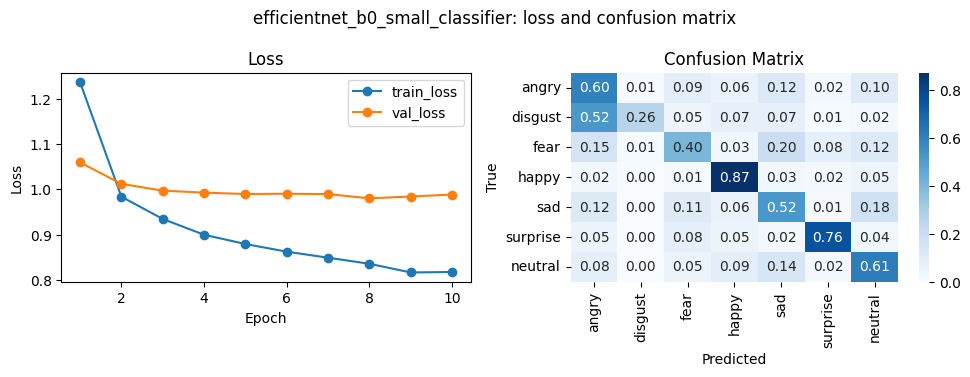

Best checkpoint saved to: /kaggle/working/DL-final-project/results/checkpoints/efficientnet_b0_small_classifier.pt


,precision,recall,f1-score,support
macro avg,0.624913,0.575228,0.587461,7178.0
weighted avg,0.637863,0.640429,0.636234,7178.0


,precision,recall,f1-score,support
angry,0.512043,0.599165,0.552189,958.0
disgust,0.630435,0.261261,0.369427,111.0
fear,0.516291,0.402344,0.452250,1024.0
happy,0.827531,0.870913,0.848668,1774.0
sad,0.530945,0.522855,0.526869,1247.0
surprise,0.781366,0.756919,0.768949,831.0
neutral,0.575781,0.613139,0.593873,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
28,sad,neutral,221,0.177225
15,fear,sad,202,0.197266
38,neutral,sad,178,0.144363
12,fear,angry,157,0.153320
23,sad,angry,148,0.118685
25,sad,fear,138,0.110666
17,fear,neutral,123,0.120117
3,angry,sad,118,0.123173
37,neutral,happy,109,0.088402
34,neutral,angry,99,0.080292


In [6]:
def run_efficientnet_b0_small_head(
    name='efficientnet_b0_small_classifier',
    source_checkpoint=RESULTS_DIR / 'checkpoints' / 'efficientnet_b0_gradual_unfreeze.pt',
    batch_size=64,
    num_workers=0,
    subset_fraction=1.0,
    epochs=10,
    lr=5e-5,
    unfreeze_from='last_blocks',
    classifier_hidden_layers=[256],
):
    loaders, datasets = build_transfer_loaders(batch_size=batch_size, num_workers=num_workers, subset_fraction=subset_fraction)
    model = build_model('transfer', transfer_model='efficientnet_b0', freeze_backbone=False)
    model.load_state_dict(torch.load(source_checkpoint, map_location=DEVICE))
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = torch.nn.Sequential(
        torch.nn.Linear(in_features, classifier_hidden_layers[0]),
        torch.nn.BatchNorm1d(classifier_hidden_layers[0]),
        torch.nn.ReLU(inplace=True),
        torch.nn.Dropout(0.4),
        torch.nn.Linear(classifier_hidden_layers[0], 7),
    )
    set_efficientnet_b0_trainable_layers(model, unfreeze_from)
    checkpoint_path = RESULTS_DIR / 'checkpoints' / f'{name}.pt'
    history = fit(model, loaders, device=DEVICE, epochs=epochs, lr=lr, checkpoint_path=checkpoint_path)
    save_experiment_config(name, {
        'name': name,
        'model': 'efficientnet_b0',
        'source_checkpoint': source_checkpoint,
        'classifier_hidden_layers': classifier_hidden_layers,
        'classifier_shape': '1280 -> 256 -> 7',
        'unfreeze_from': unfreeze_from,
        'epochs': epochs,
        'lr': lr,
        'selection_rule': 'highest validation macro F1; lower validation loss tie-breaker',
        'checkpoint': checkpoint_path,
    })
    return finalize_model_run(model, loaders, history, name, checkpoint_path)

history_effnet_small_head, report_effnet_small_head, confusions_effnet_small_head = run_efficientnet_b0_small_head()

In [12]:
history_frame = pd.DataFrame(history_effnet_small_head)

best_row = history_frame.sort_values(
    ['val_macro_f1', 'val_loss'],
    ascending=[False, True]
).iloc[0]

best_row[['epoch', 'train_loss', 'val_loss', 'val_macro_f1', 'val_weighted_f1']]

epoch              9.000000
train_loss         0.816889
val_loss           0.984513
val_macro_f1       0.613597
val_weighted_f1    0.636866
Name: 8, dtype: float64

## Controlled Imbalance and Loss Tuning

These experiments reload the same EfficientNet-B0 one-layer classifier checkpoint and fine-tune the last blocks. Only the imbalance/loss strategy changes.

### Class Weights

USING SQRT WEIGHTS


  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

...

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

{'epoch': 15, 'train_loss': 0.7167, 'train_macro_f1': 0.7205, 'train_weighted_f1': 0.7398, 'val_loss': 1.0556, 'val_macro_f1': 0.6096, 'val_weighted_f1': 0.6396}


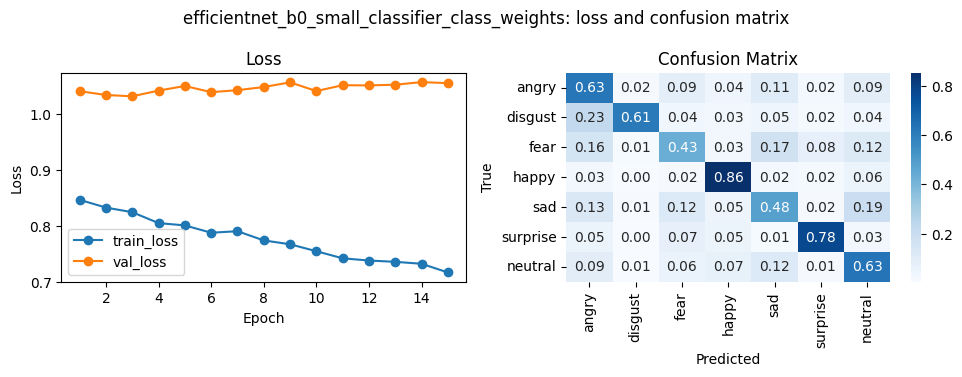

Best checkpoint saved to: /kaggle/working/DL-final-project/results/checkpoints/efficientnet_b0_small_classifier_class_weights.pt


,precision,recall,f1-score,support
macro avg,0.623864,0.630992,0.625438,7178.0
weighted avg,0.648097,0.648231,0.646246,7178.0


,precision,recall,f1-score,support
angry,0.517718,0.625261,0.566430,958.0
disgust,0.561983,0.612613,0.586207,111.0
fear,0.517564,0.431641,0.470714,1024.0
happy,0.849384,0.855130,0.852247,1774.0
sad,0.555658,0.484362,0.517566,1247.0
surprise,0.792892,0.778580,0.785671,831.0
neutral,0.571850,0.629359,0.599228,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
29,sad,neutral,241,0.193264
15,fear,sad,175,0.170898
12,fear,angry,162,0.158203
24,sad,angry,160,0.128308
26,sad,fear,153,0.122694
40,neutral,sad,148,0.120032
17,fear,neutral,122,0.119141
36,neutral,angry,117,0.094891
3,angry,sad,102,0.106472
23,happy,neutral,100,0.056370


In [14]:
def run_efficientnet_b0_controlled_tune(
    name='efficientnet_b0_small_classifier_weighted_sampler_focal',
    source_checkpoint=RESULTS_DIR / 'checkpoints' / 'efficientnet_b0_small_classifier.pt',
    batch_size=64,
    num_workers=0,
    subset_fraction=1.0,
    epochs=15,
    lr=5e-5,
    unfreeze_from='last_blocks',
    classifier_hidden_layers=[256],
    use_class_weights=False,
    weighted_sampler=True,
    loss_name='focal',
    focal_gamma=1.0,
):
    loaders, datasets = build_transfer_loaders(
        batch_size=batch_size,
        num_workers=num_workers,
        subset_fraction=subset_fraction,
        weighted_sampler=weighted_sampler,
    )
    model = build_model(
        'transfer',
        transfer_model='efficientnet_b0',
        freeze_backbone=False,
        classifier_hidden_layers=classifier_hidden_layers,
        classifier_dropout=0.4,
    )
    model.load_state_dict(torch.load(source_checkpoint, map_location=DEVICE))
    set_efficientnet_b0_trainable_layers(model, unfreeze_from)
    weights = class_weights(dataset_labels(datasets['train'])) if use_class_weights else None
    checkpoint_path = RESULTS_DIR / 'checkpoints' / f'{name}.pt'
    history = fit(
        model,
        loaders,
        device=DEVICE,
        epochs=epochs,
        lr=lr,
        class_weight=weights,
        loss_name=loss_name,
        focal_gamma=focal_gamma,
        checkpoint_path=checkpoint_path,
    )
    save_experiment_config(name, {
        'name': name,
        'model': 'efficientnet_b0',
        'source_checkpoint': source_checkpoint,
        'classifier_hidden_layers': classifier_hidden_layers,
        'classifier_shape': '1280 -> 256 -> 7',
        'unfreeze_from': unfreeze_from,
        'epochs': epochs,
        'lr': lr,
        'use_class_weights': use_class_weights,
        'weighted_sampler': weighted_sampler,
        'loss_name': loss_name,
        'focal_gamma': focal_gamma,
        'selection_rule': 'highest validation macro F1; lower validation loss tie-breaker',
        'checkpoint': checkpoint_path,
    })
    return finalize_model_run(model, loaders, history, name, checkpoint_path)

history_effnet_class_weights, report_effnet_class_weights, confusions_effnet_class_weights = run_efficientnet_b0_controlled_tune(
    name='efficientnet_b0_small_classifier_class_weights',
    use_class_weights=True,
    weighted_sampler=False,
    loss_name='cross_entropy',
    focal_gamma=1.0,
)

In [15]:
history_frame = pd.DataFrame(history_effnet_class_weights)

best_row = history_frame.sort_values(
    ['val_macro_f1', 'val_loss'],
    ascending=[False, True]
).iloc[0]

best_row[['epoch', 'train_loss', 'val_loss', 'val_macro_f1', 'val_weighted_f1']]

epoch              12.000000
train_loss          0.738009
val_loss            1.051530
val_macro_f1        0.616608
val_weighted_f1     0.642280
Name: 11, dtype: float64

### WeightedRandomSampler

USING SQRT WEIGHTS


  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

...

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

{'epoch': 15, 'train_loss': 0.6999, 'train_macro_f1': 0.7468, 'train_weighted_f1': 0.7385, 'val_loss': 1.0257, 'val_macro_f1': 0.604, 'val_weighted_f1': 0.6364}


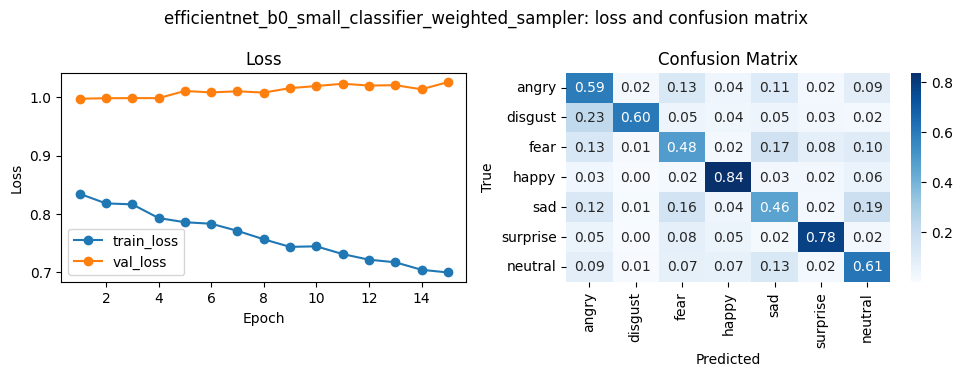

Best checkpoint saved to: /kaggle/working/DL-final-project/results/checkpoints/efficientnet_b0_small_classifier_weighted_sampler.pt


,precision,recall,f1-score,support
macro avg,0.614287,0.624744,0.618537,7178.0
weighted avg,0.641731,0.640290,0.640103,7178.0


,precision,recall,f1-score,support
angry,0.523063,0.591858,0.555338,958.0
disgust,0.549180,0.603604,0.575107,111.0
fear,0.485323,0.484375,0.484848,1024.0
happy,0.860789,0.836528,0.848485,1774.0
sad,0.535814,0.461909,0.496124,1247.0
surprise,0.764429,0.780987,0.772619,831.0
neutral,0.581413,0.613950,0.597239,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
29,sad,neutral,232,0.186047
26,sad,fear,199,0.159583
15,fear,sad,173,0.168945
40,neutral,sad,155,0.125710
24,sad,angry,153,0.122694
12,fear,angry,136,0.132812
1,angry,fear,121,0.126305
36,neutral,angry,108,0.087591
3,angry,sad,105,0.109603
17,fear,neutral,104,0.101562


In [18]:
history_effnet_weighted_sampler, report_effnet_weighted_sampler, confusions_effnet_weighted_sampler = run_efficientnet_b0_controlled_tune(
    name='efficientnet_b0_small_classifier_weighted_sampler',
    use_class_weights=False,
    weighted_sampler=True,
    loss_name='cross_entropy',
    focal_gamma=1.0,
)

### Focal Loss

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

...

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

{'epoch': 15, 'train_loss': 0.4958, 'train_macro_f1': 0.715, 'train_weighted_f1': 0.7362, 'val_loss': 0.7571, 'val_macro_f1': 0.6131, 'val_weighted_f1': 0.6431}


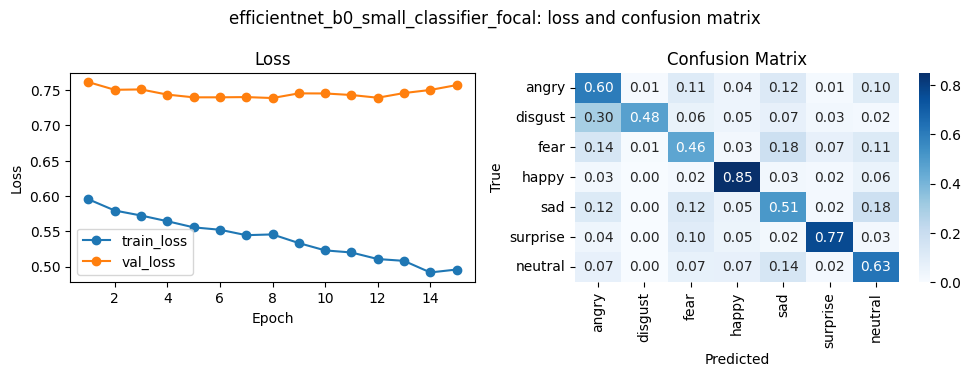

Best checkpoint saved to: /kaggle/working/DL-final-project/results/checkpoints/efficientnet_b0_small_classifier_focal.pt


,precision,recall,f1-score,support
macro avg,0.637816,0.613151,0.622741,7178.0
weighted avg,0.648666,0.648370,0.647675,7178.0


,precision,recall,f1-score,support
angry,0.539757,0.602296,0.569314,958.0
disgust,0.662500,0.477477,0.554974,111.0
fear,0.503751,0.458984,0.480327,1024.0
happy,0.848706,0.850620,0.849662,1774.0
sad,0.538007,0.510826,0.524064,1247.0
surprise,0.792289,0.766546,0.779205,831.0
neutral,0.579699,0.625304,0.601639,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
28,sad,neutral,225,0.180433
15,fear,sad,184,0.179688
39,neutral,sad,175,0.141930
25,sad,fear,151,0.121091
12,fear,angry,144,0.140625
23,sad,angry,144,0.115477
17,fear,neutral,117,0.114258
3,angry,sad,113,0.117954
1,angry,fear,103,0.107516
22,happy,neutral,98,0.055242


In [19]:
history_effnet_focal, report_effnet_focal, confusions_effnet_focal = run_efficientnet_b0_controlled_tune(
    name='efficientnet_b0_small_classifier_focal',
    use_class_weights=False,
    weighted_sampler=False,
    loss_name='focal',
    focal_gamma=1.0,
)

In [20]:
history_effnet_focal = pd.DataFrame(history_effnet_class_weights)

best_row = history_frame.sort_values(
    ['val_macro_f1', 'val_loss'],
    ascending=[False, True]
).iloc[0]

best_row[['epoch', 'train_loss', 'val_loss', 'val_macro_f1', 'val_weighted_f1']]

epoch              12.000000
train_loss          0.738009
val_loss            1.051530
val_macro_f1        0.616608
val_weighted_f1     0.642280
Name: 11, dtype: float64

### Class Weights + Focal Loss

USING SQRT WEIGHTS


  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

...

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

{'epoch': 15, 'train_loss': 0.3492, 'train_macro_f1': 0.7155, 'train_weighted_f1': 0.7307, 'val_loss': 0.5325, 'val_macro_f1': 0.6065, 'val_weighted_f1': 0.6408}


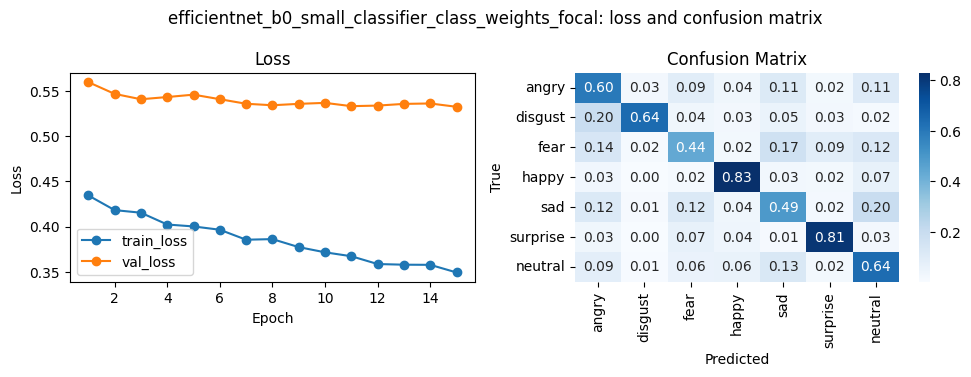

Best checkpoint saved to: /kaggle/working/DL-final-project/results/checkpoints/efficientnet_b0_small_classifier_class_weights_focal.pt


,precision,recall,f1-score,support
macro avg,0.612523,0.634479,0.620600,7178.0
weighted avg,0.647292,0.645584,0.644556,7178.0


,precision,recall,f1-score,support
angry,0.533085,0.597077,0.563269,958.0
disgust,0.496503,0.639640,0.559055,111.0
fear,0.525324,0.435547,0.476241,1024.0
happy,0.869976,0.829763,0.849394,1774.0
sad,0.545293,0.492382,0.517488,1247.0
surprise,0.759322,0.808664,0.783217,831.0
neutral,0.558156,0.638281,0.595535,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
29,sad,neutral,247,0.198075
15,fear,sad,176,0.171875
40,neutral,sad,157,0.127332
26,sad,fear,149,0.119487
24,sad,angry,148,0.118685
12,fear,angry,140,0.136719
17,fear,neutral,126,0.123047
23,happy,neutral,120,0.067644
3,angry,sad,109,0.113779
5,angry,neutral,105,0.109603


In [21]:
history_effnet_class_weights_focal, report_effnet_class_weights_focal, confusions_effnet_class_weights_focal = run_efficientnet_b0_controlled_tune(
    name='efficientnet_b0_small_classifier_class_weights_focal',
    use_class_weights=True,
    weighted_sampler=False,
    loss_name='focal',
    focal_gamma=1.0,
)

### WeightedRandomSampler + Focal Loss

In [ ]:
# history_effnet_weighted_sampler_focal, report_effnet_weighted_sampler_focal, confusions_effnet_weighted_sampler_focal = run_efficientnet_b0_controlled_tune(
#     name='efficientnet_b0_small_classifier_weighted_sampler_focal',
#     use_class_weights=False,
#     weighted_sampler=True,
#     loss_name='focal',
#     focal_gamma=1.0,
# )

## Merge EfficientNet-B0 Results

Run this after finishing several EfficientNet-B0 cells. It reads saved metric files and creates one comparison table without retraining.

In [22]:
summary_names = [
    'efficientnet_b0_gradual_unfreeze',
    'efficientnet_b0_small_classifier',
    'efficientnet_b0_small_classifier_class_weights',
    'efficientnet_b0_small_classifier_weighted_sampler',
    'efficientnet_b0_small_classifier_focal',
    'efficientnet_b0_small_classifier_class_weights_focal',
    # 'efficientnet_b0_small_classifier_weighted_sampler_focal',
]

summary_rows = {}
metrics_dir = RESULTS_DIR / 'metrics'
for name in summary_names:
    report_path = metrics_dir / f'{name}_classification_report.csv'
    history_path = metrics_dir / f'{name}_history.csv'
    confusions_path = metrics_dir / f'{name}_top_confusions.csv'
    if not report_path.exists() or not history_path.exists():
        continue
    report = pd.read_csv(report_path, index_col=0)
    history = pd.read_csv(history_path)
    confusions = pd.read_csv(confusions_path) if confusions_path.exists() else pd.DataFrame()
    summary_rows[name] = {
        'final_val_loss': float(history['val_loss'].iloc[-1]),
        'best_val_loss': float(history['val_loss'].min()),
        'final_val_macro_f1': float(history['val_macro_f1'].iloc[-1]),
        'best_val_macro_f1': float(history['val_macro_f1'].max()),
        'test_macro_f1': float(report.loc['macro avg', 'f1-score']),
        'test_weighted_f1': float(report.loc['weighted avg', 'f1-score']),
        'top_confusion': 'none' if confusions.empty else f"{confusions.iloc[0]['true_emotion']} -> {confusions.iloc[0]['predicted_emotion']}",
    }

efficientnet_b0_summary = pd.DataFrame(summary_rows).T.sort_values('test_macro_f1', ascending=False)
efficientnet_b0_summary.to_csv(metrics_dir / 'efficientnet_b0_experiment_summary.csv')
efficientnet_b0_summary

,final_val_loss,best_val_loss,final_val_macro_f1,best_val_macro_f1,test_macro_f1,test_weighted_f1,top_confusion
efficientnet_b0_small_classifier_class_weights,1.055615,1.032032,0.609573,0.616608,0.625438,0.646246,sad -> neutral
efficientnet_b0_small_classifier_focal,0.757114,0.73879,0.613107,0.622168,0.622741,0.647675,sad -> neutral
efficientnet_b0_small_classifier_class_weights_focal,0.532476,0.532476,0.60651,0.60651,0.6206,0.644556,sad -> neutral
efficientnet_b0_small_classifier_weighted_sampler,1.025696,0.997256,0.603951,0.608981,0.618537,0.640103,sad -> neutral
efficientnet_b0_small_classifier,0.98889,0.980501,0.611902,0.613597,0.587461,0.636234,sad -> neutral
efficientnet_b0_gradual_unfreeze,0.979026,0.979026,0.611427,0.611427,0.583126,0.631598,sad -> neutral


In [24]:
!git add -f results/
!git config --global user.name "zsykk"
!git config --global user.email "shaoya.zhang01@estudiant.upf.edu"

In [ ]:
!git pull --rebase origin main
!git commit -m "Add FER2013 experiment results"
!git push

error: cannot pull with rebase: Your index contains uncommitted changes.
error: please commit or stash them.
[main 118d9b3] Add FER2013 experiment results
 19 files changed, 172 insertions(+)
 create mode 100644 results/checkpoints/efficientnet_b0_small_classifier_class_weights_focal.pt
 create mode 100644 results/checkpoints/efficientnet_b0_small_classifier_focal.pt
 create mode 100644 results/checkpoints/efficientnet_b0_small_classifier_weighted_sampler.pt
 create mode 100644 results/figures/efficientnet_b0_small_classifier_class_weights_focal_confusion_matrix.png
 create mode 100644 results/figures/efficientnet_b0_small_classifier_focal_confusion_matrix.png
 create mode 100644 results/figures/efficientnet_b0_small_classifier_weighted_sampler_confusion_matrix.png
 create mode 100644 results/metrics/efficientnet_b0_experiment_summary.csv
 create mode 100644 results/metrics/efficientnet_b0_small_classifier_class_weights_focal_classification_report.csv
 create mode 100644 results/metric